Installing libraries (if necessary)

In [7]:
from __future__ import annotations

import os
import json
import math
import re
import random
import itertools
from collections import defaultdict
from typing import Iterable
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.collocations import TrigramCollocationFinder

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

[nltk_data] Downloading package punkt to /home/ferran/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/ferran/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Trigram division of the training and test data. Adding them to a `.json` file.

In [17]:
def generate_trigrams_json(input_json_path, output_json_path, min_freq=2):
    """
    Llegeix un JSON amb el corpus (idioma: text), calcula els trigrames
    i guarda un nou JSON amb el format (idioma: {trigrama: freqüència}).
    """
    if not os.path.exists(input_json_path):
        print(f"No s'ha trobat l'arxiu: {input_json_path}")
        return

    # 1. Carregar l'arxiu JSON
    with open(input_json_path, 'r', encoding='utf-8') as f:
        corpus = json.load(f)

    trigrams_data = {}

    # 2. Processar cada idioma
    print(f"\n=== Processant trigrames per a '{input_json_path}' ===")
    for lang, text in corpus.items():
        print(f"  Calculant {lang}...")
        
        # En passar-li un string, from_words itera lletra per lletra (n-grames de caràcters)
        finder = TrigramCollocationFinder.from_words(text)
        
        # 3. Aplicar el filtre de freqüència que has indicat
        if min_freq > 1:
            finder.apply_freq_filter(min_freq)
        
        # 4. Convertir els resultats al format 'trigrama': n_ocurrències
        lang_trigrams = {}
        for ngram_tuple, count in finder.ngram_fd.items():
            # Juntem la tupla ('t', 'h', 'e') per fer l'string "the"
            trigram_str = "".join(ngram_tuple)
            lang_trigrams[trigram_str] = count
            
        trigrams_data[lang] = lang_trigrams

    # 5. Guardar el resultat en un nou JSON
    with open(output_json_path, 'w', encoding='utf-8') as f:
        json.dump(trigrams_data, f, ensure_ascii=False)

    print(f"-> Guardat correctament a: {output_json_path}")


# Executem la funció per als dos arxius (train i test)
# Pots modificar min_freq=2 si vols un filtre diferent (o posar 1 per no filtrar-ne cap)
generate_trigrams_json('./corpus_train.json', './trigrams_train.json', min_freq=5)



=== Processant trigrames per a './corpus_train.json' ===
  Calculant deu...
  Calculant eng...
  Calculant fra...
  Calculant ita...
  Calculant nld...
  Calculant spa...
-> Guardat correctament a: ./trigrams_train.json


## 1. Lidstone Smoothing, following this formula:

$$
P^T(e_j) = P^T_{LID}(e_j)= \frac{C_t(e_j) + \lambda}{N_t + \lambda B}
$$

- $e_j$: Trigram to determine (or sentence)
- $B$: Number of different trigrams in the train corpus
- $N_t$: Number of trigrams in the train corpus
- $C_t(e_j)$: Number of occurencies of $e_j$ in the train corpus.

We fit the model with the training data, returning a `.json` file with the parameters $B$ and $N_t$, and a the list of trigrams with their counts i the train corpus, for each language.

The inference is made by maximizing the likelihood of the test document given the language model:

$$
\arg\max_{L} P(\hat{d} \mid L)
$$

Which is estimated using Maximum Likelihood Estimation (MLE) (assuming independence)

$$
P(\hat{d}) = P(e_1, \dots, e_s) = \prod_{j=1}^{s} P(e_j)
$$

Equivalenty;

$$
\log P(\hat{d}) = \sum_{j=1}^{s} \log P(e_j)
$$

Instead of multiplying probabilities in a massive loop, the code adds logarithms:
```python
log_prob_total += text_occurrences * math.log(prob_seen)
```

In [2]:
class LidstoneLanguageModel:
    def __init__(self, lambda_val=0.5):
        """
        Inicialitza el model amb un valor de lambda (λ).
        """
        self.lambda_val = lambda_val
        self.model_params = {}

    def fit(self, train_trigrams_json, output_model_json):
        """
        Llegeix el JSON de trigrames d'entrenament, calcula N_t i B per a cada idioma,
        i guarda els paràmetres i el corpus en un nou arxiu JSON.
        """
        if not os.path.exists(train_trigrams_json):
            raise FileNotFoundError(f"No s'ha trobat: {train_trigrams_json}")

        with open(train_trigrams_json, 'r', encoding='utf-8') as f:
            trigrams_data = json.load(f)

        for lang, trigrams_dict in trigrams_data.items():
            # N_t = Nombre total de trigrames en el corpus d'aquest idioma
            N_t = sum(trigrams_dict.values())
            
            # B = Nombre de trigrames diferents (mida del vocabulari d'aquest idioma)
            B = len(trigrams_dict.keys())
            
            self.model_params[lang] = {
                "lambda": self.lambda_val,
                "N_t": N_t,
                "B": B,
                "counts": trigrams_dict
            }

        # Guardem els paràmetres en un nou JSON
        with open(output_model_json, 'w', encoding='utf-8') as f:
            json.dump(self.model_params, f, ensure_ascii=False, indent=2)
            
        print(f"Model entrenat i paràmetres guardats a: {output_model_json}")

    def load_model(self, model_json):
        """
        Carrega els paràmetres d'un model prèviament entrenat.
        """
        if not os.path.exists(model_json):
            raise FileNotFoundError(f"No s'ha trobat el model a: {model_json}")
            
        with open(model_json, 'r', encoding='utf-8') as f:
            self.model_params = json.load(f)
        print(f"Model carregat correctament des de: {model_json}")

    def predict_text(self, text):
        """
        Donat un text pla preprocessat (sense dividir en trigrames),
        calcula la probabilitat per cada idioma i retorna el més probable.
        """
        if not self.model_params:
            raise ValueError("El model no està carregat. Fes .fit() o .load_model() abans.")

        # 1. Extreure els trigrames del text a predir (test)
        finder = TrigramCollocationFinder.from_words(text)
        test_trigrams = {"".join(k): v for k, v in finder.ngram_fd.items()}

        scores = {}

        # 2. Calcular la probabilitat per a cada idioma, seguint MLE.
        for lang, params in self.model_params.items():
            L = params["lambda"]
            N_t = params["N_t"]
            B = params["B"]
            counts = params["counts"]

            # Denominador de la fórmula de Lidstone: (N_t + λ * B)
            denominator = N_t + (L * B)
            
            # Probabilitat per a un trigrama no vist al corpus d'entrenament (C_t = 0)
            prob_unseen = L / denominator if denominator > 0 else 1e-10
            log_prob_unseen = math.log(prob_unseen) if prob_unseen > 0 else float('-inf')

            log_prob_total = 0.0

            # Apliquem la fórmula a cada trigrama del text
            for trigram, text_occurrences in test_trigrams.items():
                C_t = counts.get(trigram, 0)
                
                if C_t > 0:
                    # Si el trigrama existeix al corpus d'entrenament
                    prob_seen = (C_t + L) / denominator
                    log_prob_total += text_occurrences * math.log(prob_seen)
                else:
                    # Si és un trigrama desconegut (Out Of Vocabulary)
                    log_prob_total += text_occurrences * log_prob_unseen

            scores[lang] = log_prob_total
            
        # 3. Escollir l'idioma amb el logaritme de probabilitat més alt (el menys negatiu)
        best_lang = max(scores, key=scores.get)
        return best_lang, scores
    
    def refining_lambda(self, model_json, k_folds=4):
        """
        Refina el valor de lambda per a cada idioma utilitzant validació creuada sobre les dades de train.
        Maximitza l'Accuracy (percentatge d'encerts) simulant la predicció contra la resta d'idiomes.
        Desa el nou fitxer amb les lambdes modificades sobreescrivint l'original.
        """
        if not self.model_params:
            self.load_model(model_json)
            
        lambdas_to_test = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1.0]
        
        for lang, params in self.model_params.items():
            print(f"Refinant lambda per a: {lang}...")
            counts = params["counts"]
            
            # Converteix el diccionari de freqüències en una llista d'elements
            # Expandim els trigrames segons les vegades que apareixen
            trigrams_list = []
            for trigram, count in counts.items():
                trigrams_list.extend([trigram] * count)
                
            # Si hi ha pocs trigrames, evitem error
            if len(trigrams_list) < k_folds:
                print(f"  Pocs trigrames per {lang}, es manté la lambda actual.")
                continue
                
            # Modelem una proporció d'split equivalent al 75-25 remenant les dades
            random.shuffle(trigrams_list)
            fold_size = len(trigrams_list) // k_folds
            
            best_lambda = params["lambda"]
            best_accuracy = -1.0  # L'accuracy va de 0 a 1, inicialitzem en negatiu
            
            # Evaluar cadascuna de les lambdes
            for l_candidate in lambdas_to_test:
                avg_accuracy = 0.0
                
                # Apliquem Cross-Validation manual (ex: 4 folds = 75% train / 25% test rotatiu)
                for i in range(k_folds):
                    # Definició de Train i Validation Split 
                    val_start = i * fold_size
                    val_end = (i + 1) * fold_size if i != k_folds - 1 else len(trigrams_list)
                    
                    val_set = trigrams_list[val_start:val_end]
                    train_set = trigrams_list[:val_start] + trigrams_list[val_end:]
                    
                    # Generem estadístiques del train fold actual
                    train_counts = {}
                    for t in train_set:
                        train_counts[t] = train_counts.get(t, 0) + 1
                    
                    fold_Nt = len(train_set)
                    fold_B = len(train_counts)
                    fold_denominator = fold_Nt + (l_candidate * fold_B)
                    fold_unseen_prob = l_candidate / fold_denominator if fold_denominator > 0 else 1e-10
                    fold_log_unseen = math.log(fold_unseen_prob) if fold_unseen_prob > 0 else float('-inf')
                    
                    correct_predictions = 0
                    
                    # Avaluem L'ACCURACY classificant cada trigrama de validació
                    for t_val in val_set:
                        # 1. Puntuació (Score) que atorga l'idioma actual (train_set)
                        ct = train_counts.get(t_val, 0)
                        if ct > 0:
                            prob_seen = (ct + l_candidate) / fold_denominator
                            score_current = math.log(prob_seen)
                        else:
                            score_current = fold_log_unseen
                            
                        # 2. Comprovar si l'idioma actual venç a la resta d'idiomes del model
                        is_best = True
                        for other_lang, other_params in self.model_params.items():
                            if other_lang == lang:
                                continue
                            
                            # Paràmetres globals dels altres idiomes (estàtics durant aquesta comparació)
                            oL = other_params["lambda"]
                            oNt = other_params["N_t"]
                            oB = other_params["B"]
                            o_counts = other_params["counts"]
                            
                            o_denom = oNt + (oL * oB)
                            o_prob_unseen = oL / o_denom if o_denom > 0 else 1e-10
                            o_log_unseen = math.log(o_prob_unseen) if o_prob_unseen > 0 else float('-inf')
                            
                            o_ct = o_counts.get(t_val, 0)
                            if o_ct > 0:
                                o_prob = (o_ct + oL) / o_denom
                                score_other = math.log(o_prob)
                            else:
                                score_other = o_log_unseen
                                
                            # Si un altre idioma puntua el trigrama millor, perdem l'encert
                            if score_other >= score_current:
                                is_best = False
                                break
                                
                        # Si cap idioma supera la puntuació del nostre, és un encert
                        if is_best:
                            correct_predictions += 1
                    
                    # Accuracy d'aquest fold: encerts / total de mostres al fold
                    fold_accuracy = correct_predictions / len(val_set)
                    avg_accuracy += fold_accuracy
                
                # Mitjana total de l'Accuracy de tots els k_folds
                avg_accuracy /= k_folds
                print(f"  Lambda {l_candidate}: Accuracy = {avg_accuracy * 100:.2f}%, Idioma: {lang}")
                
                # Ara volem l'accuracy MÉS ALTA possible (més a prop de 1.0)
                if avg_accuracy > best_accuracy:
                    best_accuracy = avg_accuracy
                    best_lambda = l_candidate
            
            print(f"  Millor lambda per a {lang}: {best_lambda} (Accuracy: {best_accuracy * 100:.2f}%)")
            
            # Actualitzem els paràmetres locals amb la nova lambda guanyadora
            self.model_params[lang]["lambda"] = best_lambda

        # Sobreescriu el fitxer JSON amb les lambdes recalibrades
        with open(model_json, 'w', encoding='utf-8') as f:
            json.dump(self.model_params, f, ensure_ascii=False, indent=2)
            
        print(f"Refinament completat. Les lambdes optimitzades s'han sobreescrit a: {model_json}")

    
    def evaluate_model(self, test_corpus_json):
        """
        Avalua el model amb un corpus de test, dividit per frases, i mostra la matriu de confusió i el classification report.
        Cada frase del test corpus ha de tenir d'estar separada per doble espai i el format del JSON ha de ser {idioma: "frase1  frase2  frase3 ..."}.
        """
        if not self.model_params:
            raise ValueError("El model no està carregat. Fes .fit() o .load_model() abans.")
        
        if not os.path.exists(test_corpus_json):
            raise FileNotFoundError(f"No s'ha trobat el corpus de test a: {test_corpus_json}")
        
        with open(test_corpus_json, 'r', encoding='utf-8') as f:
            test_corpus = json.load(f)
        
        y_true = []
        y_pred = []
        
        for lang, text in test_corpus.items():
            # Suposem que les frases estan separades per doble espai
            sentences = text.split("  ")
            accuracy_lang = 0
            for sentence in sentences:
                sentence = sentence.strip()
                if sentence:  # Evitem frases buides
                    pred_lang, _ = self.predict_text(sentence)
                    y_true.append(lang)
                    y_pred.append(pred_lang)
                    accuracy_lang += (pred_lang == lang)
                    if lang != pred_lang:
                        print(f"Frase mal classificada: '{sentence}' (True: {lang} -> Predicted: {pred_lang})")
            print(f"Idioma: {lang}, Frases processades: {len(sentences)}, Accuracy parcial: {accuracy_lang / len(sentences) * 100:.2f}%")
        
        
        return confusion_matrix(y_true, y_pred), classification_report(y_true, y_pred)

        

In [8]:
model = LidstoneLanguageModel(lambda_val=0.5)
#model.fit('./trigrams_train.json', './lidstone_model.json')

In [9]:
model.load_model('./lidstone_model.json')

Model carregat correctament des de: ./lidstone_model.json


In [3]:
model.refining_lambda('./lidstone_model.json', k_folds=4)

NameError: name 'model' is not defined

In [10]:
matrix, report = model.evaluate_model('./corpus_test.json')

Frase mal classificada: 'er studierte an der rhode island school of design.' (True: deu -> Predicted: nld)
Frase mal classificada: 'einer wie crosby?' (True: deu -> Predicted: nld)
Frase mal classificada: 'er lebt heute im karmapa buddhist international institute (kibi) in new delhi (indien).' (True: deu -> Predicted: nld)
Frase mal classificada: 'mit channing tatum, amanda seyfried. the last song ( mit dir an meiner seite) mit miley cyrus, liam hemsworth.' (True: deu -> Predicted: eng)
Frase mal classificada: 'bénédicte de peretti bénédicte de peretti ist gründerin und managing partner bei bp communications consulting.' (True: deu -> Predicted: fra)
Frase mal classificada: 'onlangs was er een beachvolleybaltoernoei in baal, de heimat van nys.' (True: deu -> Predicted: nld)
Frase mal classificada: 'ton zeichnet sie kamera entweder als .-kanal (avchd) oder in stereo (xavc s) auf.' (True: deu -> Predicted: nld)
Frase mal classificada: 'im android open source project (aosp) existiert bere

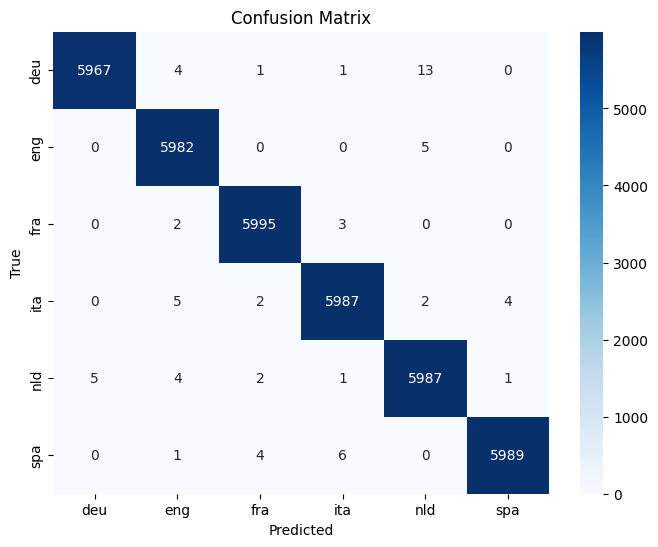

Classification Report:
               precision    recall  f1-score   support

         deu       1.00      1.00      1.00      5986
         eng       1.00      1.00      1.00      5987
         fra       1.00      1.00      1.00      6000
         ita       1.00      1.00      1.00      6000
         nld       1.00      1.00      1.00      6000
         spa       1.00      1.00      1.00      6000

    accuracy                           1.00     35973
   macro avg       1.00      1.00      1.00     35973
weighted avg       1.00      1.00      1.00     35973



In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.model_params.keys(), yticklabels=model.model_params.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()      
print("Classification Report:\n", report)

## 2. Interpolation smoothing


The idea of Interpolation smoothing is to stop relying only on trigrams to estimate the probability, and combine:
- Trigrams
- Bigrams
- Unigrams

For a trigram model: 

$$
P^T(e_j \mid e_{j-2}, e_{j-1}) =
\lambda_3 \frac{C_t(e_{j-2}, e_{j-1}, e_j)}{C_t(e_{j-2}, e_{j-1})}
+
\lambda_2 \frac{C_t(e_{j-1}, e_j)}{C_t(e_{j-1})}
+
\lambda_1 \frac{C_t(e_j)}{N_t}
$$

$$
\lambda_1 + \lambda_2 + \lambda_3 = 1
\quad \text{and} \quad
\lambda_i \ge 0
$$

In [25]:


from __future__ import annotations

import json
import math
import os
import re
import itertools
from collections import defaultdict
from typing import Iterable

import matplotlib.pyplot as plt
from nltk.collocations import TrigramCollocationFinder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def _extract_trigrams(text: str) -> dict[str, int]:
    """Extreu trigrames de caràcters d'un text i retorna el diccionari de freqüències."""
    finder = TrigramCollocationFinder.from_words(text)
    return {"".join(k): v for k, v in finder.ngram_fd.items()}


def _build_ngram_counts(trigram_counts: dict[str, int]) -> tuple[
    dict[str, int], dict[str, int], dict[str, int], dict[str, int]
]:
    """
    A partir dels trigrames, construeix els comptadors de tots els n-grames
    necessaris per a la interpolació:

        trigrama  "abc"  → P(c | ab)
        bigrama   "bc"   → P(c | b)   ← sufixos, no prefixos!
        unigrama  "c"    → P(c)

    Retorna (trigram_counts, bigram_counts, unigram_counts, context_counts)
    on context_counts["ab"] = nombre total d'ocurrències del context "ab".
    """

    # Bigrames com a context per als trigrames: "ab" → total de trigrames que comencen per "ab"
    context3_counts: dict[str, int] = defaultdict(int)
    # Bigrames com a seqüència "bc" (els dos últims caràcters del trigrama)
    bigram_counts: dict[str, int] = defaultdict(int)
    # Context de bigrama: "b" → total de bigrames que comencen per "b"
    context2_counts: dict[str, int] = defaultdict(int)
    # Unigrames: "c" (l'últim caràcter del trigrama)
    unigram_counts: dict[str, int] = defaultdict(int)

    for trigram, count in trigram_counts.items():
        if len(trigram) != 3:
            continue
        a, b, c = trigram[0], trigram[1], trigram[2]

        context3_counts[a + b] += count   # context del trigrama
        bigram_counts[b + c]   += count   # bigrama "bc"
        context2_counts[b]     += count   # context del bigrama
        unigram_counts[c]      += count   # unigrama "c"

    return (
        dict(trigram_counts),
        dict(bigram_counts),
        dict(unigram_counts),
        dict(context3_counts),
        dict(context2_counts),
    )



class InterpolationLanguageModel:
    """
    Model de detecció d'idioma basat en trigrames de caràcters amb
    Linear Interpolation Smoothing.

    """

    # Fixem les lambdes que usarem per el model
    DEFAULT_LAMBDAS = (0.05, 0.10, 0.25, 0.60)

    def __init__(self, lambdas: tuple[float, float, float, float] | None = None):
        """

        Valida i inicialitza les lambdes

        """
        lambdas = lambdas or self.DEFAULT_LAMBDAS
        self._validate_lambdas(lambdas)
        self.lambdas = lambdas
        self.model_params: dict = {}


    @staticmethod
    def _validate_lambdas(lambdas: tuple) -> None:
        """

        Valida les lambdes: hi han d'haver-hi exactament 4, no poden ser negatives i han de sumar 1. 
        Si alguna condició no es compleix, llencem un missatge d'error

        """
        if len(lambdas) != 4:
            raise ValueError("Cal passar exactament 4 lambdes: (λ₀, λ₁, λ₂, λ₃).")
        if any(l < 0 for l in lambdas):
            raise ValueError("Tots els lambdes han de ser ≥ 0.")
        if not math.isclose(sum(lambdas), 1.0, abs_tol=1e-6):
            raise ValueError(f"Els lambdes han de sumar 1. Suma actual: {sum(lambdas):.6f}")


    def fit(self, train_trigrams_json: str, output_model_json: str | None = None) -> None:
        """
        Entrena el model a partir d'un JSON de trigrames del corpus.

        El JSON ha de tenir el format:  { idioma: { trigrama: freqüència } }
        """

        # Si no es troba l'arxiu, llencem missatge d'error
        if not os.path.exists(train_trigrams_json):
            raise FileNotFoundError(f"No s'ha trobat: {train_trigrams_json}")

        # Obrim el fitxer i el convertim a un diccionari de python
        with open(train_trigrams_json, "r", encoding="utf-8") as f:
            trigrams_data = json.load(f)

        # Crida a mètode intern 
        self._fit_from_dict(trigrams_data)

        # Si s'ha especificat una ruta de sortida es guarda el model
        if output_model_json:
            with open(output_model_json, "w", encoding="utf-8") as f:
                json.dump(self.model_params, f, ensure_ascii=False, indent=2)
            print(f"Model entrenat i guardat a: {output_model_json}")
        else:
            print("Model entrenat (no s'ha guardat en disc).")


    def _fit_from_dict(self, trigrams_data: dict[str, dict[str, int]]) -> None:
        """
        Versió interna de fit que accepta el diccionari directament.

        """
        self.model_params = {}
        for lang, trigram_counts in trigrams_data.items():
            (
                tc, bigram_counts, unigram_counts,
                context3_counts, context2_counts
            ) = _build_ngram_counts(trigram_counts)
            
            # Nombre total de caràcters considerats
            N1 = sum(unigram_counts.values())

            # Nombre de caràcters diferents
            V  = len(unigram_counts)

            # Guardem els paràmetres
            self.model_params[lang] = {
                "lambdas":         list(self.lambdas),
                "trigram_counts":  tc,
                "bigram_counts":   bigram_counts,
                "unigram_counts":  unigram_counts,
                "context3_counts": context3_counts, 
                "context2_counts": context2_counts,  
                "N1":              N1,
                "V":               V,
            }


    def load_model(self, model_json: str) -> None:

        """Carrega els paràmetres d'un model prèviament entrenat."""

        # Si el model no es troba llença un missatge d'error
        if not os.path.exists(model_json):
            raise FileNotFoundError(f"No s'ha trobat el model a: {model_json}")

        with open(model_json, "r", encoding="utf-8") as f:
            self.model_params = json.load(f)
        print(f"Model carregat correctament des de: {model_json}")


    def _interpolated_log_prob(
        self,
        trigram: str,
        params: dict,
        lambdas: tuple[float, float, float, float] | None = None,
    ) -> float:
        """

        Calcula log P_interp(c | ab) per a un idioma concret.

        """

        # Si l'usuari ha passat lambdes noves les usem
        l0, l1, l2, l3 = lambdas if lambdas is not None else params["lambdas"]

        # Carrega totes les dades necessàries
        trigram_counts   = params["trigram_counts"]
        bigram_counts    = params["bigram_counts"]
        unigram_counts   = params["unigram_counts"]
        context3_counts  = params["context3_counts"]
        context2_counts  = params["context2_counts"]
        N1 = params["N1"]
        V  = params["V"]

        # Separem el trigram
        ab = trigram[:2]   
        b  = trigram[1]   
        c  = trigram[2]   

        # Estimadors condicionals correctes
        c_ab  = context3_counts.get(ab, 0)
        p3    = trigram_counts.get(trigram, 0) / c_ab if c_ab > 0 else 0.0

        c_b   = context2_counts.get(b, 0)
        p2    = bigram_counts.get(b + c, 0) / c_b if c_b > 0 else 0.0

        p1    = unigram_counts.get(c, 0) / N1 if N1 > 0 else 0.0
        p0    = 1.0 / V if V > 0 else 0.0

        prob = l3 * p3 + l2 * p2 + l1 * p1 + l0 * p0

        return math.log(prob) if prob > 0 else float("-inf")


    def _score_text(
        self,
        test_trigrams: dict[str, int],
        lambdas: tuple[float, float, float, float] | None = None,
    ) -> dict[str, float]:
        """Calcula el log-score interpolat per a cada idioma."""
        scores: dict[str, float] = {}
        for lang, params in self.model_params.items():
            scores[lang] = sum(
                freq * self._interpolated_log_prob(trigram, params, lambdas)
                for trigram, freq in test_trigrams.items()
            )
        return scores


    def predict_text(
        self,
        text: str,
        lambdas: tuple[float, float, float, float] | None = None,
    ) -> tuple[str, dict[str, float]]:
        """
        Donat un text pla preprocessat, retorna l'idioma més probable i els scores.

        Paràmetres
        ----------
        text    : text a classificar
        lambdas : si s'indica, s'usen aquests pesos en lloc dels del model
        """
        if not self.model_params:
            raise ValueError("El model no està carregat. Fes .fit() o .load_model() primer.")

        test_trigrams = _extract_trigrams(text)
        if not test_trigrams:
            raise ValueError("El text no conté trigrames vàlids.")

        scores   = self._score_text(test_trigrams, lambdas)
        best_lang = max(scores, key=scores.get)
        return best_lang, scores

    def evaluate(
        self,
        test_json: str,
        lambdas: tuple[float, float, float, float] | None = None,
        show_plot: bool = True,
    ) -> tuple[float, any]:
        """
        Avalua el model sobre un JSON de test.
        
        """
        if not os.path.exists(test_json):
            raise FileNotFoundError(f"No s'ha trobat: {test_json}")

        with open(test_json, "r", encoding="utf-8") as f:
            test_corpus = json.load(f)

        y_true, y_pred = [], []
        labels = sorted(test_corpus.keys())

        errors = []

        for true_lang, full_text in test_corpus.items():
            frases = [f.strip() for f in re.split(r' {2,}|\n+', full_text) if len(f.strip()) > 5]

            for frase in frases:
                try:
                    predicted_lang, _ = self.predict_text(frase, lambdas)
                except ValueError:
                    continue

                y_true.append(true_lang)
                y_pred.append(predicted_lang)

                if true_lang != predicted_lang:
                    errors.append({
                        "true": true_lang,
                        "pred": predicted_lang,
                        "text": frase
                    })

        print("Report de Classificació:")
        print(classification_report(y_true, y_pred, labels=labels))

        cm = confusion_matrix(y_true, y_pred, labels=labels)

        if show_plot:
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
            disp.plot(cmap="Blues", values_format="d")
            plt.title("Matriu de Confusió d'Identificació d'Idioma")
            plt.tight_layout()
            plt.show()

        accuracy = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true) if y_true else 0.0
        return accuracy, cm, errors


In [26]:
model2 = InterpolationLanguageModel()

In [27]:
model2.fit('./trigrams_train.json', './interpolation_model.json')

Model entrenat i guardat a: ./interpolation_model.json


In [28]:
model2.load_model('./interpolation_model.json')

Model carregat correctament des de: ./interpolation_model.json


In [29]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

Report de Classificació:
              precision    recall  f1-score   support

         deu       1.00      1.00      1.00      5986
         eng       1.00      1.00      1.00      5987
         fra       1.00      1.00      1.00      6000
         ita       1.00      1.00      1.00      6000
         nld       1.00      1.00      1.00      6000
         spa       1.00      1.00      1.00      6000

    accuracy                           1.00     35973
   macro avg       1.00      1.00      1.00     35973
weighted avg       1.00      1.00      1.00     35973



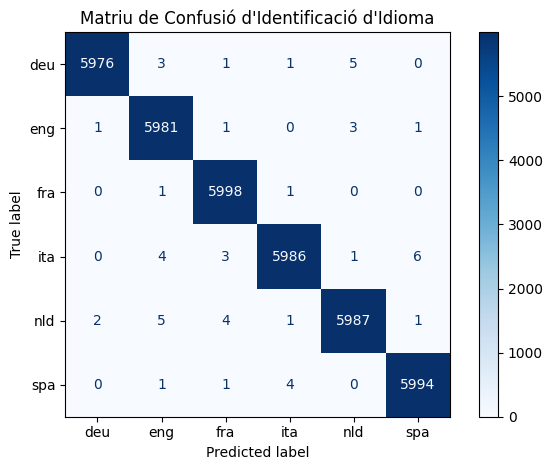

[REAL=deu | PRED=eng] er lebt heute im karmapa buddhist international institute (kibi) in new delhi (indien).
[REAL=deu | PRED=eng] mit channing tatum, amanda seyfried. the last song ( mit dir an meiner seite) mit miley cyrus, liam hemsworth.
[REAL=deu | PRED=fra] bénédicte de peretti bénédicte de peretti ist gründerin und managing partner bei bp communications consulting.
[REAL=deu | PRED=nld] onlangs was er een beachvolleybaltoernoei in baal, de heimat van nys.
[REAL=deu | PRED=eng] im android open source project (aosp) existiert bereits ein fix.
[REAL=deu | PRED=nld] nyborg: hvad er din foretrukne bevaringsværdige bygning i nyborg kommune?
[REAL=deu | PRED=ita] dritter wurde andrea iannone (ita/ducati).
[REAL=deu | PRED=nld] het consumentenvertrouwen is er in januari geklommen naar het hoogste niveau in elf jaar.
[REAL=deu | PRED=nld] den saudiskledede koalition støtter de regeringstro grupper mod andre oprørere, der er støttet af iran. indsatsen består i både luftangreb, landtroppe

In [30]:
accuracy, cm, errors = model2.evaluate('./corpus_test.json')

for e in errors:
    print(f"[REAL={e['true']} | PRED={e['pred']}] {e['text']}")